# Resource Allocation Grid Search

Sweeps `bw_split` and `comp_split` over 9 × 9 = 81 combinations (0.1 → 0.9),
runs each combination 3 times with different seeds, and records
mean **AoRI**, mean **AoSI**, and **throughput** (bits transmitted / step).

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

from metalore.scenarios import SingleCellEnv
from metalore.config import isac_vehicle_config

print('MetaLore imported.')

MetaLore imported.


In [2]:
# --- Grid search parameters ---
SPLITS  = [round(v, 1) for v in np.arange(0.1, 0.95, 0.1)]   # [0.1, 0.2, ..., 0.9]
SEEDS   = list(range(4))
N_STEPS = 100

print(f'bw/comp splits : {SPLITS}')
print(f'Seeds          : {len(SEEDS)} seeds (0–99)')
print(f'Combinations   : {len(SPLITS)**2} splits × {len(SEEDS)} seeds = {len(SPLITS)**2 * len(SEEDS)} runs')

bw/comp splits : [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9)]
Seeds          : 4 seeds (0–99)
Combinations   : 81 splits × 4 seeds = 324 runs


In [3]:
def run_episode(bw_split, comp_split, seed, n_steps=N_STEPS):
    """Run one episode with fixed allocation and return episode metrics dict."""
    cfg = isac_vehicle_config()
    cfg['environment']['seed'] = seed
    cfg['environment']['max_steps'] = n_steps
    cfg['environment']['reset_rng_episode'] = True

    env = SingleCellEnv(config=cfg)
    env.reset()

    action = [bw_split, comp_split]
    for _ in range(n_steps):
        _, _, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            break

    ep = env.metrics.finalize(env.job_tracker)
    steps_run = env.metrics.num_steps

    return {
        'mean_aori':  ep['mean_aori'],
        'mean_aosi':  ep['mean_aosi'],
        'throughput': ep['bits_transmitted'] / steps_run if steps_run > 0 else 0.0,
    }


# --- Main loop ---
rows = []
total_runs = len(SPLITS) ** 2 * len(SEEDS)
done = 0

for bw, comp in product(SPLITS, SPLITS):
    seed_results = []
    for seed in SEEDS:
        result = run_episode(bw, comp, seed)
        seed_results.append(result)
        rows.append({
            'bw_split':   bw,
            'comp_split': comp,
            'seed':       seed,
            'mean_aori':  result['mean_aori'],
            'mean_aosi':  result['mean_aosi'],
            'throughput': result['throughput'],
        })
        done += 1

    if done % (len(SEEDS) * 9) == 0 or done == total_runs:
        print(f'[{done}/{total_runs}]  bw={bw:.1f}  comp={comp:.1f}  done')

raw_df = pd.DataFrame(rows)
print(f'\nTotal rows collected: {len(raw_df)}')
raw_df.head(9)

[36/324]  bw=0.1  comp=0.9  done
[72/324]  bw=0.2  comp=0.9  done
[108/324]  bw=0.3  comp=0.9  done
[144/324]  bw=0.4  comp=0.9  done
[180/324]  bw=0.5  comp=0.9  done
[216/324]  bw=0.6  comp=0.9  done
[252/324]  bw=0.7  comp=0.9  done
[288/324]  bw=0.8  comp=0.9  done
[324/324]  bw=0.9  comp=0.9  done

Total rows collected: 324


,bw_split,comp_split,seed,mean_aori,mean_aosi,throughput
0,0.1,0.1,0,0.472906,2.790640,555.813759
1,0.1,0.1,1,0.395238,2.407143,562.193410
2,0.1,0.1,2,0.553699,2.374702,559.670000
3,0.1,0.1,3,0.775561,2.955112,559.590000
4,0.1,0.2,0,0.435961,2.798030,555.813759
5,0.1,0.2,1,0.385714,2.411905,562.193410
6,0.1,0.2,2,0.513126,2.384248,559.670000
7,0.1,0.2,3,0.708229,2.965087,559.590000
8,0.1,0.3,0,0.435961,2.798030,555.813759


In [4]:
# --- Aggregate: mean and std over seeds per (bw_split, comp_split) ---
agg_df = (
    raw_df
    .groupby(['bw_split', 'comp_split'])[['mean_aori', 'mean_aosi', 'throughput']]
    .agg(['mean', 'std'])
    .reset_index()
)

# Flatten column names: (mean_aori, mean) → mean_aori, (mean_aori, std) → std_aori
agg_df.columns = [
    'bw_split', 'comp_split',
    'mean_aori', 'std_aori',
    'mean_aosi', 'std_aosi',
    'throughput', 'std_throughput',
]

print('Aggregated results (mean ± std over 100 seeds):')
print(agg_df[['bw_split','comp_split','mean_aori','std_aori','mean_aosi','std_aosi']].to_string(index=False))

Aggregated results (mean ± std over 100 seeds):
 bw_split  comp_split  mean_aori  std_aori  mean_aosi  std_aosi
      0.1         0.1   0.549351  0.164098   2.631899  0.286549
      0.1         0.2   0.510758  0.141694   2.639817  0.287571
      0.1         0.3   0.510758  0.141694   2.639817  0.287571
      0.1         0.4   0.510758  0.141694   2.639817  0.287571
      0.1         0.5   2.470846  0.963957   3.337677  0.098269
      0.1         0.6  12.877433  2.326858   3.933948  1.110952
      0.1         0.7  20.829657  2.600190   4.166347  1.457228
      0.1         0.8  30.268892  1.855401   3.711339  1.482256
      0.1         0.9  32.480783  5.850479   3.761599  0.745927
      0.2         0.1   0.341153  0.015040   2.477718  0.160770
      0.2         0.2   0.330419  0.017969   2.480686  0.158963
      0.2         0.3   0.330419  0.017969   2.480686  0.158963
      0.2         0.4   0.330419  0.017969   2.480686  0.158963
      0.2         0.5   1.250569  0.286327   3.523432  0

In [5]:
# --- Save to CSV ---
raw_df.to_csv('grid_search_raw.csv', index=False)
agg_df.to_csv('grid_search_agg.csv', index=False)
print('Saved: grid_search_raw.csv  (all 8100 rows)')
print('Saved: grid_search_agg.csv  (81 rows with mean + std)')

Saved: grid_search_raw.csv  (all 8100 rows)
Saved: grid_search_agg.csv  (81 rows with mean + std)


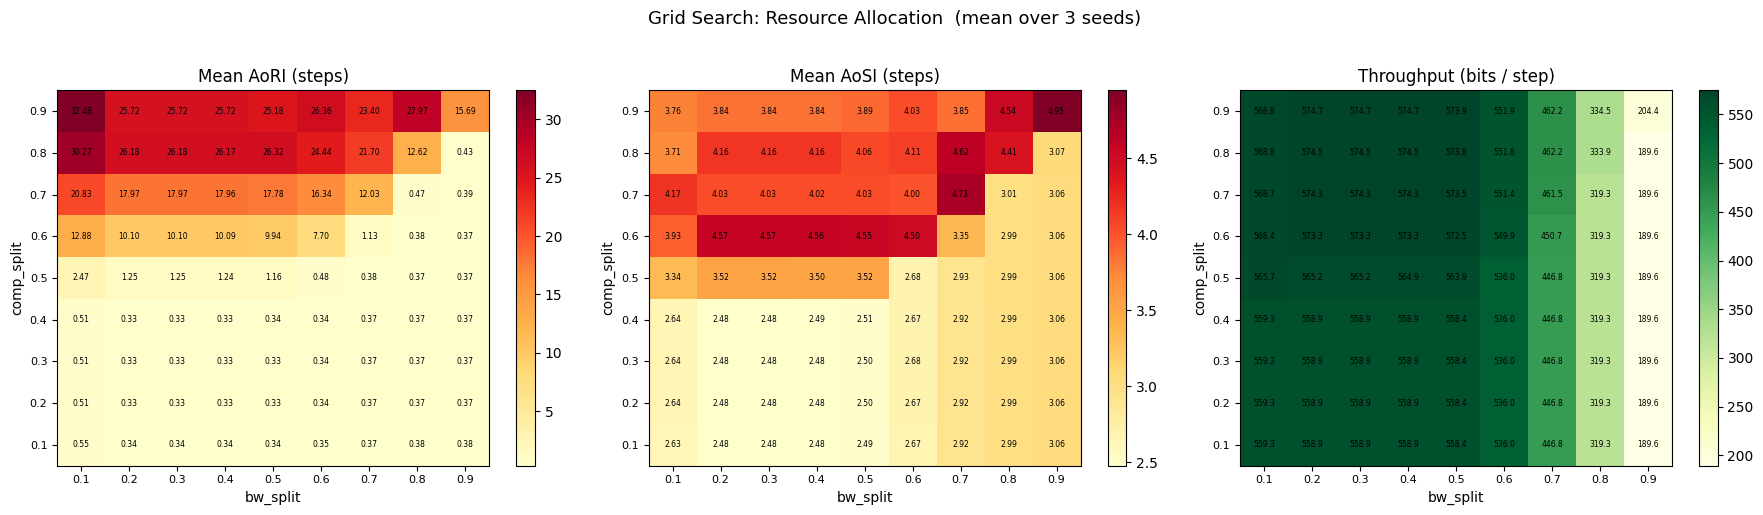

Saved: grid_search_heatmaps.png


In [6]:
def make_grid(df, metric):
    """Pivot aggregated df into a 2-D array for imshow (rows=comp_split, cols=bw_split)."""
    pivot = df.pivot(index='comp_split', columns='bw_split', values=metric)
    return pivot


metrics = [
    ('mean_aori',  'Mean AoRI (steps)',        'YlOrRd'),
    ('mean_aosi',  'Mean AoSI (steps)',        'YlOrRd'),
    ('throughput', 'Throughput (bits / step)', 'YlGn'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric, title, cmap) in zip(axes, metrics):
    grid = make_grid(agg_df, metric)

    # Drop rows / cols that are all-NaN (can happen if AoRI/AoSI never populated)
    has_data = not grid.isna().all(axis=None)

    im = ax.imshow(
        grid.values,
        origin='lower',
        aspect='auto',
        cmap=cmap,
        interpolation='nearest',
    )
    plt.colorbar(im, ax=ax)

    # Axis labels
    ax.set_xticks(range(len(SPLITS)))
    ax.set_xticklabels([f'{s:.1f}' for s in SPLITS], fontsize=8)
    ax.set_yticks(range(len(SPLITS)))
    ax.set_yticklabels([f'{s:.1f}' for s in SPLITS], fontsize=8)
    ax.set_xlabel('bw_split')
    ax.set_ylabel('comp_split')
    ax.set_title(title)

    # Annotate each cell with its value
    for i, comp in enumerate(SPLITS):
        for j, bw in enumerate(SPLITS):
            val = grid.loc[comp, bw]
            if pd.notna(val):
                text = f'{val:.1f}' if metric == 'throughput' else f'{val:.2f}'
                ax.text(j, i, text, ha='center', va='center', fontsize=5.5, color='black')

plt.suptitle('Grid Search: Resource Allocation  (mean over 3 seeds)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('grid_search_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: grid_search_heatmaps.png')

In [7]:
# --- Best allocations per metric ---
valid = agg_df.dropna(subset=['mean_aori', 'mean_aosi'])

if not valid.empty:
    best_aori  = valid.loc[valid['mean_aori'].idxmin()]
    best_aosi  = valid.loc[valid['mean_aosi'].idxmin()]
    best_tp    = agg_df.loc[agg_df['throughput'].idxmax()]

    print('Best allocation by minimum AoRI:')
    print(f"  bw={best_aori['bw_split']:.1f}  comp={best_aori['comp_split']:.1f}  "
          f"AoRI={best_aori['mean_aori']:.3f}  AoSI={best_aori['mean_aosi']:.3f}  "
          f"throughput={best_aori['throughput']:.1f}")

    print('Best allocation by minimum AoSI:')
    print(f"  bw={best_aosi['bw_split']:.1f}  comp={best_aosi['comp_split']:.1f}  "
          f"AoRI={best_aosi['mean_aori']:.3f}  AoSI={best_aosi['mean_aosi']:.3f}  "
          f"throughput={best_aosi['throughput']:.1f}")
else:
    print('AoRI/AoSI were None for all runs (no ISAC_COMM jobs completed). '
          'Only throughput comparison is available.')

best_tp = agg_df.loc[agg_df['throughput'].idxmax()]
print('Best allocation by maximum throughput:')
print(f"  bw={best_tp['bw_split']:.1f}  comp={best_tp['comp_split']:.1f}  "
      f"throughput={best_tp['throughput']:.1f} bits/step")

Best allocation by minimum AoRI:
  bw=0.2  comp=0.2  AoRI=0.330  AoSI=2.481  throughput=558.9
Best allocation by minimum AoSI:
  bw=0.2  comp=0.1  AoRI=0.341  AoSI=2.478  throughput=558.9
Best allocation by maximum throughput:
  bw=0.2  comp=0.9  throughput=574.7 bits/step


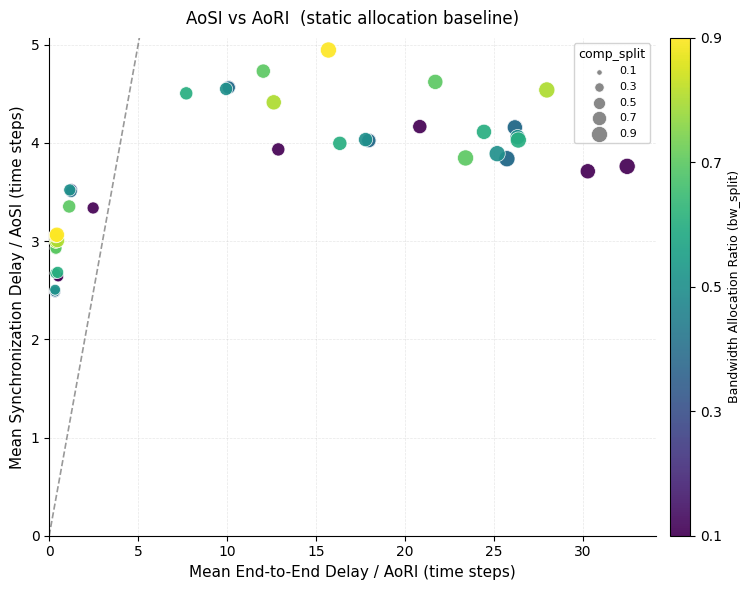

Saved: scatter_aori_aosi.png


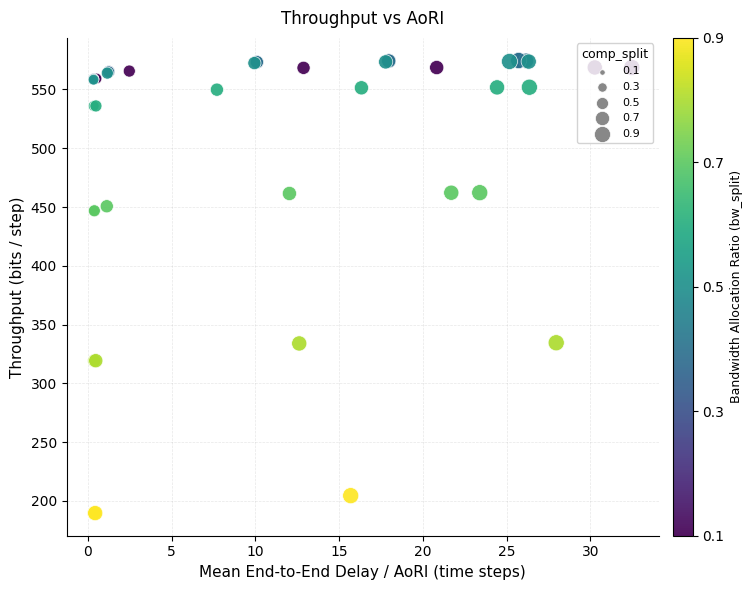

Saved: scatter_aori_throughput.png


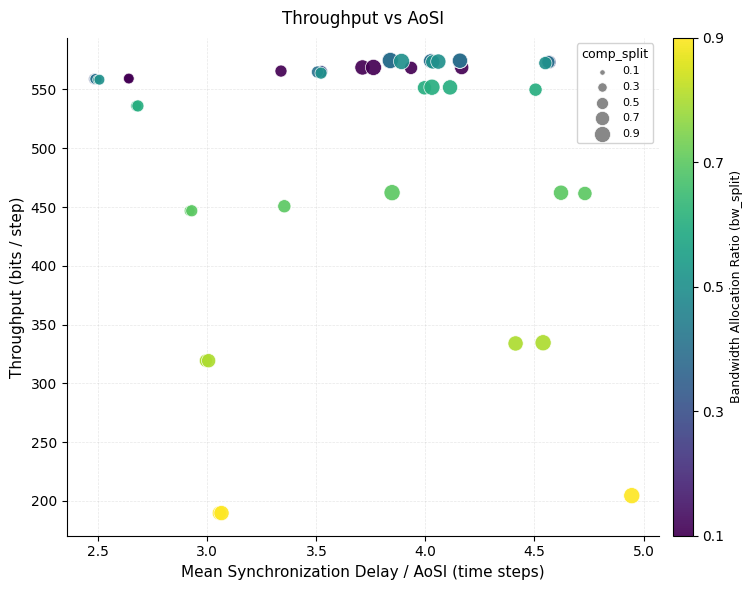

Saved: scatter_aosi_throughput.png


In [8]:
CMAP     = 'viridis'
c_vals   = agg_df['bw_split'].values
s_vals   = (agg_df['comp_split'] * 150).values   # 0.1 → 15 pt², 0.9 → 135 pt²

COMP_TICKS = [0.1, 0.3, 0.5, 0.7, 0.9]

def base_scatter(xcol, ycol, xlabel, ylabel, title, fname, diagonal=False):
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(
        agg_df[xcol], agg_df[ycol],
        c=c_vals, cmap=CMAP, vmin=0.1, vmax=0.9,
        s=s_vals, edgecolors='white', linewidths=0.5,
        alpha=0.92, zorder=3,
    )

    if diagonal:
        ax.set_xlim(left=0); ax.set_ylim(bottom=0)
        diag_max = max(agg_df[xcol].max(), agg_df[ycol].max()) * 1.05
        ax.plot([0, diag_max], [0, diag_max],
                linestyle='--', linewidth=1.2, color='#555555',
                alpha=0.6, zorder=2)

    cbar = fig.colorbar(sc, ax=ax, pad=0.02, aspect=25)
    cbar.set_label('Bandwidth Allocation Ratio (bw_split)', fontsize=9)
    cbar.set_ticks([0.1, 0.3, 0.5, 0.7, 0.9])

    size_handles = [
        ax.scatter([], [], s=c * 150, color='#888888',
                   edgecolors='white', linewidths=0.5, label=f'{c:.1f}')
        for c in COMP_TICKS
    ]
    ax.legend(handles=size_handles, title='comp_split',
              title_fontsize=9, fontsize=8,
              frameon=True, framealpha=0.85, loc='upper right')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, pad=10)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

base_scatter('mean_aori', 'mean_aosi',
             'Mean End-to-End Delay / AoRI (time steps)',
             'Mean Synchronization Delay / AoSI (time steps)',
             'AoSI vs AoRI  (static allocation baseline)',
             'scatter_aori_aosi.png', diagonal=True)

base_scatter('mean_aori', 'throughput',
             'Mean End-to-End Delay / AoRI (time steps)',
             'Throughput (bits / step)',
             'Throughput vs AoRI',
             'scatter_aori_throughput.png')

base_scatter('mean_aosi', 'throughput',
             'Mean Synchronization Delay / AoSI (time steps)',
             'Throughput (bits / step)',
             'Throughput vs AoSI',
             'scatter_aosi_throughput.png')